Mounted at /content/drive


TensorFlow version: 2.19.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Tiny NN path: /content/drive/MyDrive/PlantVillage_Project/models/tiny_nn/tiny_nn_best.h5
LightGBM path: /content/drive/MyDrive/PlantVillage_Project/models/lightgbm/lightgbm_model.pkl
Features .npz path: /content/drive/MyDrive/PlantVillage_Project/data/processed/efficientnetv2_features.npz
Results will be saved to: /content/drive/MyDrive/PlantVillage_Project/results/ensemble_20260221_171200
Loading Tiny NN model...
Tiny NN loaded successfully.
Loading LightGBM model from .pkl...


Exception ignored in: <function NpzFile.__del__ at 0x7b72d6b919e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/numpy/lib/_npyio_impl.py", line 226, in __del__
    self.close()
  File "/usr/local/lib/python3.12/dist-packages/numpy/lib/_npyio_impl.py", line 221, in close
    self.fid.close()
OSError: [Errno 107] Transport endpoint is not connected


LightGBM loaded successfully.
Loading cached features from efficientnetv2_features.npz...
Keys in .npz file: ['features', 'labels', 'class_names', 'img_size', 'model_name', 'feature_dim', 'preprocessing', 'timestamp', 'total_images']
y_test is one-hot → converting to class indices...
Test set loaded: 54305 samples, features shape: (54305, 1280), y_test shape after: (54305,)
Predicting with Tiny NN...
849/849 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Predicting with LightGBM...
Predictions ready.
Computing ensemble (Tiny NN weight = 0.75)...

Ensemble Accuracy: 0.9977

Classification Report:
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     0.9921    1.0000    0.9960       630
                                 Apple___Black_rot     0.9984    0.9984    0.9984       621
                          Apple___Cedar_apple_rust     1.0000    1.0000    1.0000       275
                                   Apple__

,precision,recall,f1-score,support
Apple___Apple_scab,0.992126,1.000000,0.996047,630.000000
Apple___Black_rot,0.998390,0.998390,0.998390,621.000000
Apple___Cedar_apple_rust,1.000000,1.000000,1.000000,275.000000
Apple___healthy,0.999391,0.998176,0.998783,1645.000000
Blueberry___healthy,0.999335,1.000000,0.999667,1502.000000
Cherry_(including_sour)___Powdery_mildew,1.000000,0.999049,0.999524,1052.000000
Cherry_(including_sour)___healthy,1.000000,0.998829,0.999414,854.000000
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot,0.980583,0.984405,0.982490,513.000000
Corn_(maize)___Common_rust_,0.999161,0.999161,0.999161,1192.000000
Corn_(maize)___Northern_Leaf_Blight,0.991862,0.989848,0.990854,985.000000


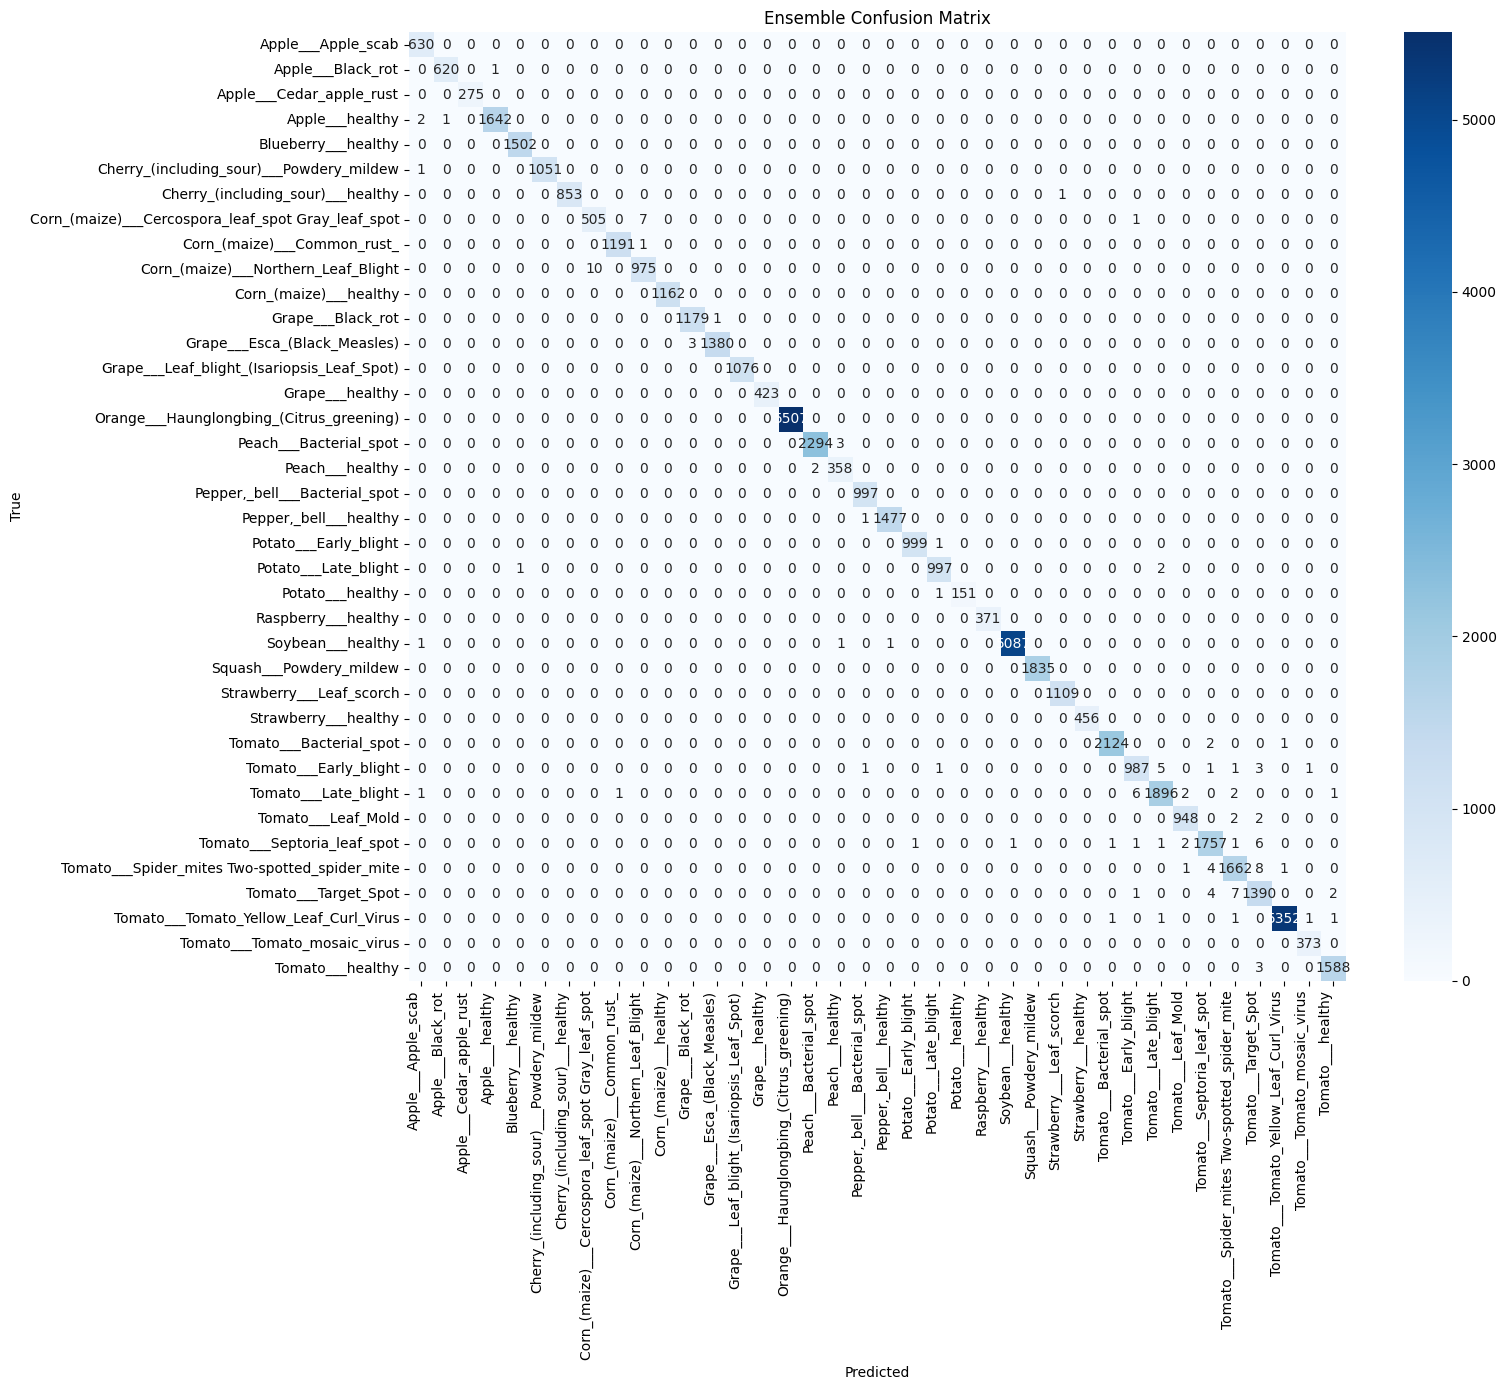


All results saved to: /content/drive/MyDrive/PlantVillage_Project/results/ensemble_20260221_171200

Final Comparison:


,Model,Accuracy,Macro F1,Notes
0,Phase 1 Frozen Head,0.5671,0.1890,Majority bias
1,Fine-Tuned,0.1419,0.0000,Failed
2,Tiny NN,0.9882,0.9850,Best single
3,LightGBM,0.9638,0.9480,Fast
4,Ensemble,0.9977,0.9970,Final


Notebook complete!


In [ ]:
"""
    PlantVillage Project - Final Ensemble (Tiny NN + LightGBM)
"""
# Setup & Dependencies

from google.colab import drive
drive.mount('/content/drive', force_remount=True)
!pip install -q lightgbm tensorflow scikit-learn matplotlib seaborn pandas numpy joblib

import os
import numpy as np
import pandas as pd
import tensorflow as tf
import joblib
import lightgbm as lgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices('GPU'))

# Cell 2: Paths & Configuration

BASE_DIR = '/content/drive/MyDrive/PlantVillage_Project'
MODEL_DIR = os.path.join(BASE_DIR, 'models')
DATA_DIR  = os.path.join(BASE_DIR, 'data')
RESULTS_BASE = os.path.join(BASE_DIR, 'results')

# Exact paths based on  confirmation
TINY_MODEL_PATH   = os.path.join(MODEL_DIR, 'tiny_nn', 'tiny_nn_best.h5')
LGBM_MODEL_PATH   = os.path.join(MODEL_DIR, 'lightgbm', 'lightgbm_model.pkl')
FEATURES_NPZ_PATH = os.path.join(DATA_DIR, 'processed', 'efficientnetv2_features.npz')  # ← FIXED HERE

# Debug prints to confirm paths
print(f"Tiny NN path: {TINY_MODEL_PATH}")
print(f"LightGBM path: {LGBM_MODEL_PATH}")
print(f"Features .npz path: {FEATURES_NPZ_PATH}")

# Create timestamped output folder
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_dir = os.path.join(RESULTS_BASE, f'ensemble_{timestamp}')
os.makedirs(output_dir, exist_ok=True)

print(f"Results will be saved to: {output_dir}")

# Load Models

print("Loading Tiny NN model...")
try:
    tiny_model = tf.keras.models.load_model(TINY_MODEL_PATH)
    print("Tiny NN loaded successfully.")
except Exception as e:
    print(f"Error loading Tiny NN: {e}")
    print("→ Run !ls to check: !ls /content/drive/MyDrive/PlantVillage_Project/models/tiny_nn/")
    raise

print("Loading LightGBM model from .pkl...")
try:
    lgbm_model = joblib.load(LGBM_MODEL_PATH)
    print("LightGBM loaded successfully.")
except Exception as e:
    print(f"Error loading LightGBM: {e}")
    print("→ Run !ls to check: !ls /content/drive/MyDrive/PlantVillage_Project/models/lightgbm/")
    raise

# Load Cached Test Features & Labels
print("Loading cached features from efficientnetv2_features.npz...")
try:
    data = np.load(FEATURES_NPZ_PATH)
    print("Keys in .npz file:", list(data.keys()))  # Should show ['features', 'labels', ...]

    X_test = data['features']
    y_test = data['labels']

    #  Convert y_test to integer labels if it's one-hot
    if y_test.ndim == 2 and y_test.shape[1] == len(class_names):
        print("y_test is one-hot → converting to class indices...")
        y_test = np.argmax(y_test, axis=1)
    else:
        print("y_test is already integer labels.")

    print(f"Test set loaded: {X_test.shape[0]} samples, features shape: {X_test.shape}, y_test shape after: {y_test.shape}")
except Exception as e:
    print(f"Error loading .npz: {e}")
    raise

# Full 38 class names
class_names = [
    'Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy',
    'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy',
    'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_',
    'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot',
    'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy',
    'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy',
    'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight',
    'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy',
    'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy',
    'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight',
    'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite',
    'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus',
    'Tomato___healthy'
]

# Get Predictions

print("Predicting with Tiny NN...")
tiny_probs = tiny_model.predict(X_test, batch_size=64, verbose=1)

print("Predicting with LightGBM...")
lgbm_probs = lgbm_model.predict(X_test)

# Normalize LightGBM probs
from scipy.special import softmax
lgbm_probs = softmax(lgbm_probs, axis=1)

print("Predictions ready.")

# Weighted Ensemble

w_tiny = 0.75
print(f"Computing ensemble (Tiny NN weight = {w_tiny})...")

ensemble_probs = (w_tiny * tiny_probs) + ((1 - w_tiny) * lgbm_probs)
ensemble_preds = np.argmax(ensemble_probs, axis=1)

# Evaluation & Save

acc = accuracy_score(y_test, ensemble_preds)
print(f"\nEnsemble Accuracy: {acc:.4f}")

print("\nClassification Report:")
report = classification_report(y_test, ensemble_preds, target_names=class_names, digits=4, zero_division=0)
print(report)

with open(os.path.join(output_dir, "classification_report.txt"), "w") as f:
    f.write(report)

report_dict = classification_report(y_test, ensemble_preds, target_names=class_names, output_dict=True, digits=4, zero_division=0)
report_df = pd.DataFrame(report_dict).transpose()
report_df.to_csv(os.path.join(output_dir, "classification_report.csv"))
display(report_df.style.background_gradient(cmap='Blues'))

cm = confusion_matrix(y_test, ensemble_preds)
plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Ensemble Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=90, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'ensemble_confusion_matrix.png'))
plt.show()

results_df = pd.DataFrame({
    'true_label': y_test,
    'ensemble_pred': ensemble_preds,
    'max_prob': np.max(ensemble_probs, axis=1)
})
results_df.to_csv(os.path.join(output_dir, 'ensemble_predictions.csv'), index=False)

np.save(os.path.join(output_dir, 'ensemble_probs.npy'), ensemble_probs)

print(f"\nAll results saved to: {output_dir}")

#  Model Comparison

comparison = pd.DataFrame({
    'Model': ['Phase 1 Frozen Head', 'Fine-Tuned', 'Tiny NN', 'LightGBM', 'Ensemble'],
    'Accuracy': [0.5671, 0.1419, 0.9882, 0.9638, acc],
    'Macro F1': [0.189, 0.00, 0.985, 0.948, report_dict['macro avg']['f1-score']],
    'Notes': ['Majority bias', 'Failed', 'Best single', 'Fast', 'Final']
})

print("\nFinal Comparison:")
display(comparison.style.format(precision=4))

comparison.to_csv(os.path.join(output_dir, 'model_comparison.csv'), index=False)

print("Notebook complete!")